In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
L                = 12
N                = 8
maxdim           = 1024
t_therm          = 40.0
alpha_list       = [
                    0.0, 
                    0.05, 0.1, 
                    0.15, 0.2, 0.25,
                    ]
seed_list = [42]   # fixed Hamiltonian disorder seed (H_SEED)
label            = "cool_01"   # initial-condition params label (the chosen params/ file)

In [3]:
boundary_exclude = 1
cmap      = plt.get_cmap('tab10')
color_map = {alpha: cmap(i) for i, alpha in enumerate(alpha_list)}

In [4]:
def load_seed_alpha_data(L, maxdim, alpha, seed, label):
    filename = Path(f"results/compressibility/n_profile_vs_t_L{L}_chi{maxdim}_alpha{alpha}_seed{seed}_{label}.csv")
    try:
        with open(filename) as f:
            comment_lines = [ln for ln in f if ln.startswith('#')]
    except FileNotFoundError:
        print(f"Warning: file not found: {filename}")
        return None

    # New files carry two header comments (# params_file = ... then # E0 = ...);
    # pick the E0 line explicitly rather than assuming it is the first line.
    E0_lines = [ln for ln in comment_lines if ln.strip().startswith('# E0')]
    if not E0_lines:
        raise ValueError(f"No '# E0 =' header in {filename}")
    E0 = float(E0_lines[0].split('=')[1])

    df = pd.read_csv(filename, comment='#')

    required = ['time'] + [f'n_{j+1}' for j in range(L)]
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {filename}: {missing}")

    times    = df['time'].values
    n_matrix = np.column_stack([df[f'n_{j+1}'].values for j in range(L)])
    assert n_matrix.shape == (len(times), L), f"Shape mismatch: {n_matrix.shape}"
    return (times, n_matrix, E0)


data = {}
for seed in seed_list:
    data[seed] = {}
    for alpha in alpha_list:
        result = load_seed_alpha_data(L, maxdim, alpha, seed, label)
        if result is not None:
            data[seed][alpha] = result


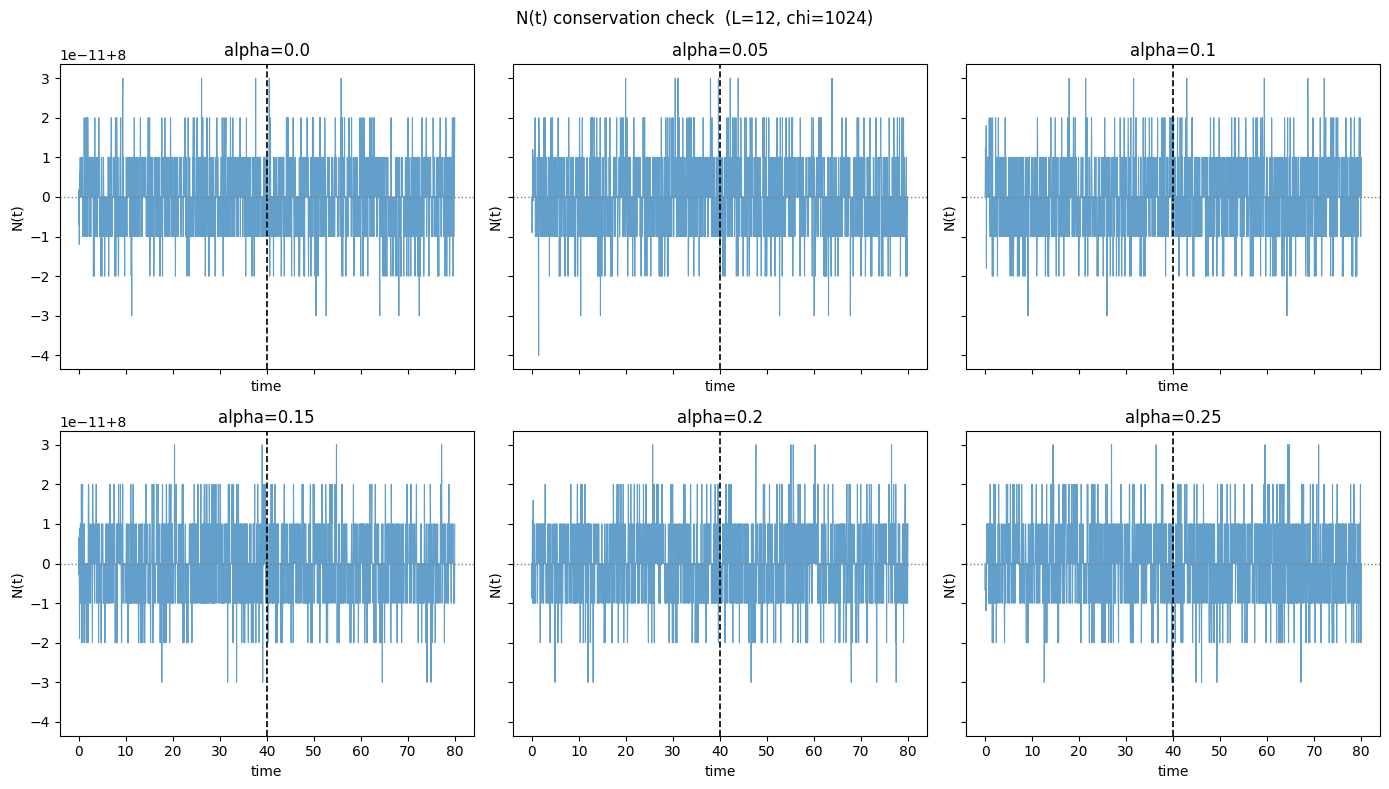

In [5]:
# Sanity check: N(t) = sum_j n_j(t) — all 5 seeds overlaid, one subplot per alpha
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, alpha in enumerate(alpha_list):
    ax = axes[i]
    for seed in seed_list:
        if alpha in data[seed]:
            times, n_matrix, E0 = data[seed][alpha]
            N_t = n_matrix.sum(axis=1)
            ax.plot(times, N_t, lw=0.8, alpha=0.7, label=f'seed={seed}')
    ax.axvline(t_therm, color='k', linestyle='--', lw=1.2, label=f't_therm={t_therm}')
    ax.axhline(N, color='gray', linestyle=':', lw=1.0, label=f'N={N}')
    ax.set_title(f'alpha={alpha}')
    ax.set_xlabel('time')
    ax.set_ylabel('N(t)')
    # if i == 0:
    #     ax.legend(fontsize=7)

fig.suptitle(f'N(t) conservation check  (L={L}, chi={maxdim})', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
def time_average_profile(times, n_matrix, t_therm):
    mask = times >= t_therm
    if not np.any(mask):
        raise ValueError(
            f"No time steps at or after t_therm={t_therm}. "
            f"Max time in data: {times.max()}"
        )
    n_late    = n_matrix[mask]
    n_samples = n_late.shape[0]
    n_bar     = n_late.mean(axis=0)
    n_err     = n_late.std(axis=0, ddof=1) / np.sqrt(n_samples)
    return n_bar, n_err

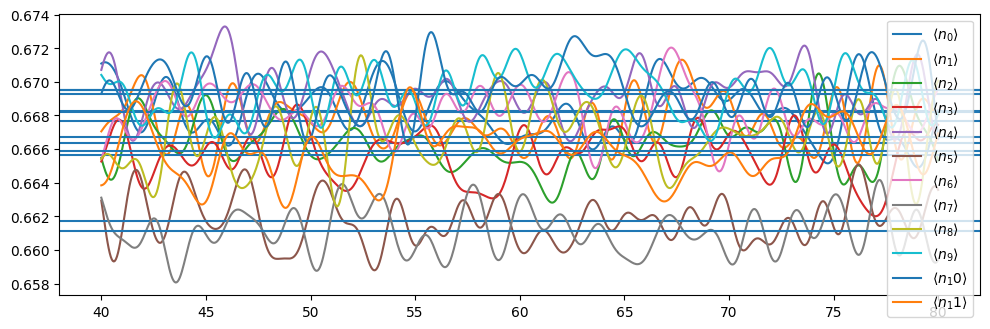

In [7]:
plt.figure(figsize=(10,3.5))
for seed in seed_list:
    times, n_matrix, E0 = data[seed][0.0]
    n_bar, n_err        = time_average_profile(times, n_matrix, t_therm)
    for i in range(L):
        plt.plot(times[800:], n_matrix[800:, i],label=rf"$\langle n_{i} \rangle$")
        plt.axhline(n_bar[i])
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
j_arr = np.arange(L)

n_bar_dic = {}

for seed in seed_list:
    for i, alpha in enumerate(alpha_list):
        times, n_matrix, E0 = data[seed][alpha]
        n_bar, _ = time_average_profile(times, n_matrix, t_therm)
        n_bar_dic[i] = n_bar

In [9]:
n_bar_dic.keys()

dict_keys([0, 1, 2, 3, 4, 5])

In [10]:
diff_arr = []
for i in n_bar_dic[0]:
    diff = i - N/L
    diff_arr.append(diff)
    print(diff)

0.0016095274470034893
0.0010138282899876394
-0.0002792306076152551
-0.0010104569742696023
0.002618737852234876
-0.004931775028664154
0.0015445610569037038
-0.005534102773008254
7.512573836365721e-05
0.0028566331503990794
0.002831653604319806
-0.000794501756366528


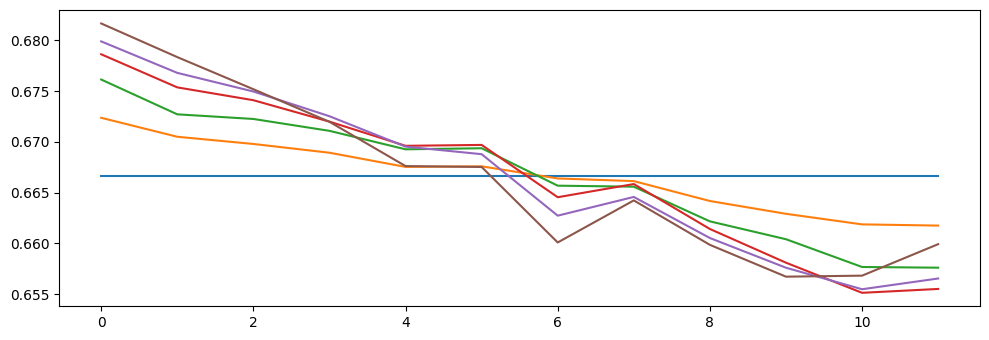

In [11]:
plt.figure(figsize=(10,3.5))
for i, alpha in enumerate(alpha_list):
    plt.plot(j_arr, n_bar_dic[i] - diff_arr)
plt.tight_layout()
plt.show()

In [12]:
n_bar_smooth_dic = {}
for i, alpha in enumerate(alpha_list):
    n_bar_smooth_dic[i] = n_bar_dic[i] - diff_arr

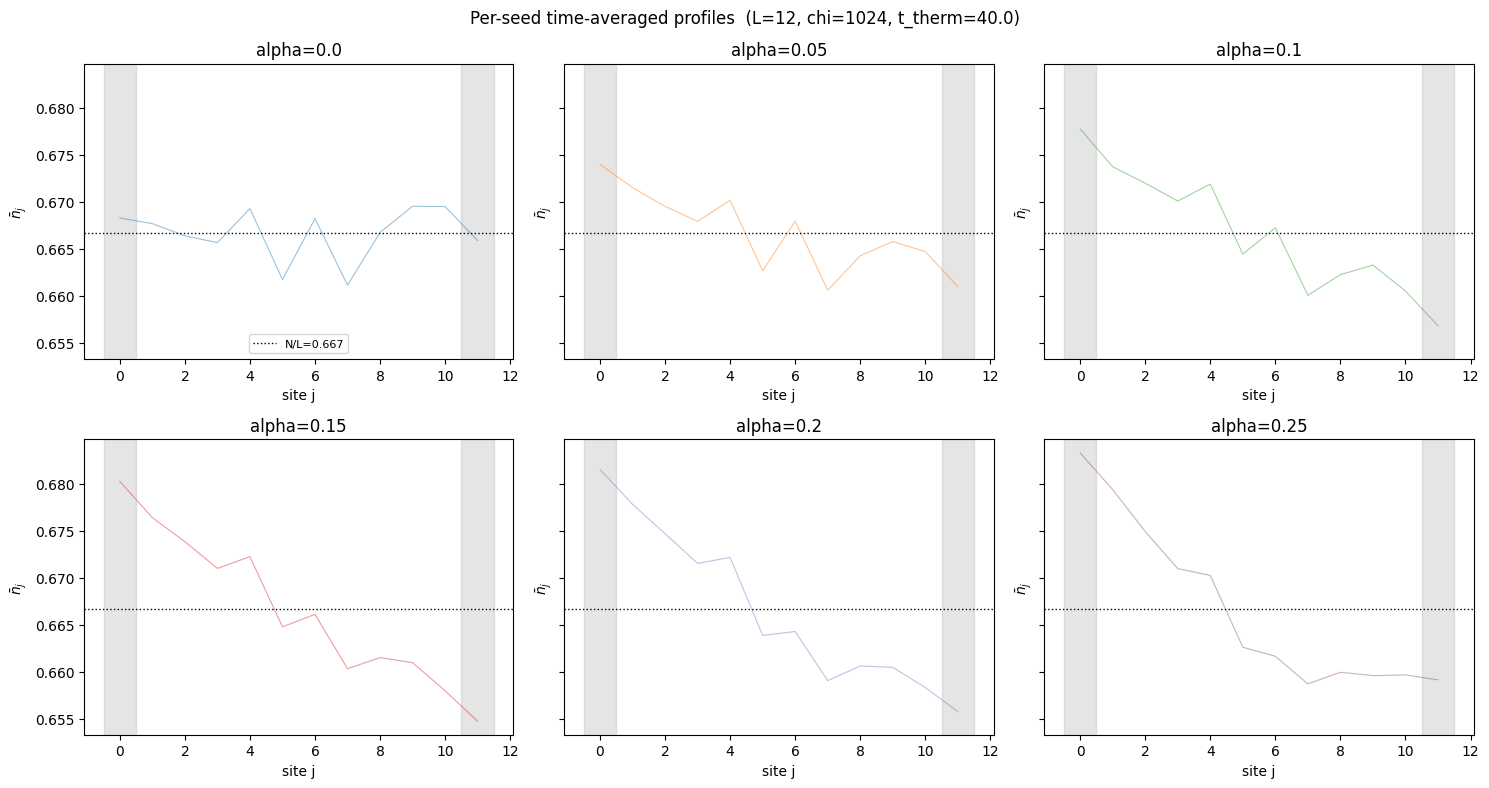

In [13]:
# Per-seed density profiles: thin lines per seed, thick line = 5-seed mean
j_arr = np.arange(L)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for i, alpha in enumerate(alpha_list):
    ax = axes[i]
    ax.axvspan(-0.5, boundary_exclude - 0.5, color='gray', alpha=0.2)
    ax.axvspan(L - boundary_exclude - 0.5, L - 0.5, color='gray', alpha=0.2)

    ax.plot(j_arr, n_bar_dic[i], lw=0.8, alpha=0.45, color=color_map[alpha])
    ax.axhline(N / L, color='k', linestyle=':', lw=1.0, label=f'N/L={N/L:.3f}')


    ax.set_title(f'alpha={alpha}')
    ax.set_xlabel('site j')
    ax.set_ylabel(r'$\bar{n}_j$')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    f'Per-seed time-averaged profiles  (L={L}, chi={maxdim}, t_therm={t_therm})',
    fontsize=12
)
plt.tight_layout()
plt.show()

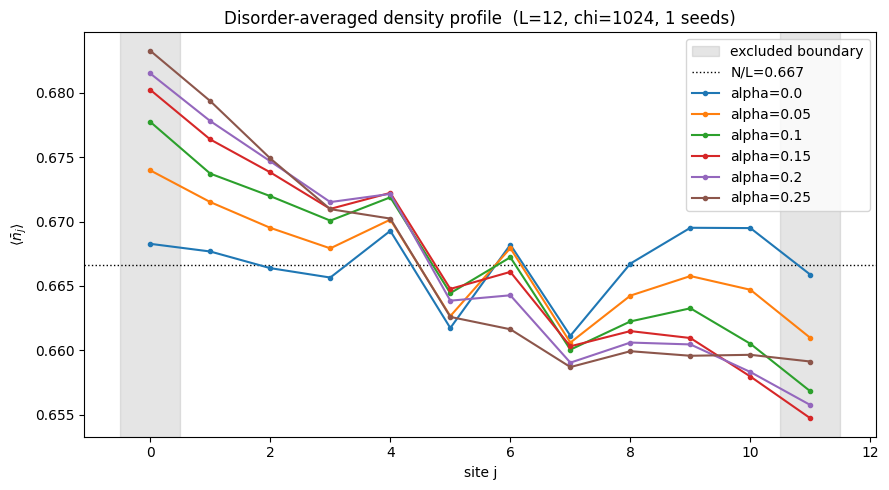

In [14]:
# Disorder-averaged profiles: <n̄_j> = mean over all 5 seeds
j_arr = np.arange(L)

# avg_profiles = {}
# for alpha in alpha_list:
#     seed_profiles = []
#     for seed in seed_list:
#         if alpha in data[seed]:
#             times, n_matrix, E0 = data[seed][alpha]
#             n_bar, _ = time_average_profile(times, n_matrix, t_therm)
#             seed_profiles.append(n_bar)
#     if seed_profiles:
#         avg_profiles[alpha] = np.mean(seed_profiles, axis=0)
#         print(f"alpha={alpha}: averaged over {len(seed_profiles)} seeds")

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(-0.5, boundary_exclude - 0.5, color='gray', alpha=0.2, label='excluded boundary')
ax.axvspan(L - boundary_exclude - 0.5, L - 0.5, color='gray', alpha=0.2)
ax.axhline(N / L, color='k', linestyle=':', lw=1.0, label=f'N/L={N/L:.3f}')

# for alpha, n_bar in avg_profiles.items():
for i, alpha in enumerate(alpha_list):
    ax.plot(j_arr, n_bar_dic[i], '-o', markersize=3, color=color_map[alpha], label=f'alpha={alpha}')

ax.set_title(
    f'Disorder-averaged density profile  '
    f'(L={L}, chi={maxdim}, {len(seed_list)} seeds)'
)
ax.set_xlabel('site j')
ax.set_ylabel(r'$\langle\bar{n}_j\rangle$')
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_16054/1472499921.py:39: RuntimeWarning: Mean of empty slice
  kappas_mean[alpha] = np.nanmean(stack, axis=0)
/opt/anaconda3/envs/codingDMRG/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


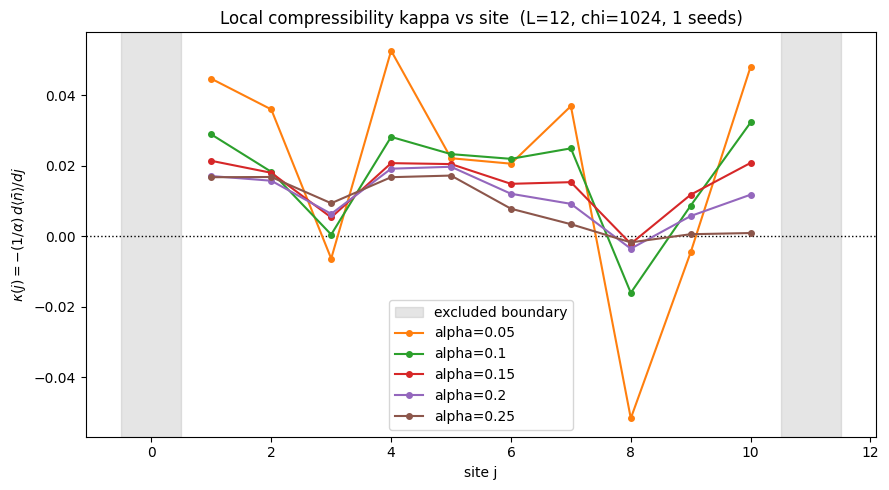

In [15]:
def compute_kappa(n_bar, alpha, boundary_exclude):
    dn_dj = np.gradient(n_bar)
    kappa = -(1.0 / alpha) * dn_dj
    L_loc = len(n_bar)
    for j in range(L_loc):
        if j < boundary_exclude or j >= L_loc - boundary_exclude:
            kappa[j] = np.nan
    return kappa


kappas_mean = {}
kappas_std  = {}

# for alpha in alpha_list:
#     if alpha == 0.0:
#         continue
#     per_seed_kappa = []
#     for seed in seed_list:
#         if alpha in data[seed]:
#             times, n_matrix, E0 = data[seed][alpha]
#             n_bar, _ = time_average_profile(times, n_matrix, t_therm)
#             kappa_seed = compute_kappa(n_bar, alpha, boundary_exclude)
#             per_seed_kappa.append(kappa_seed)
#     if per_seed_kappa:
#         stack = np.array(per_seed_kappa)           # shape (n_seeds, L)
#         kappas_mean[alpha] = np.nanmean(stack, axis=0)
#         kappas_std[alpha]  = np.nanstd(stack, axis=0, ddof=1) / np.sqrt(stack.shape[0])

for i, alpha in enumerate(alpha_list):
    if alpha == 0.0:
        continue
    per_seed_kappa = []
    for seed in seed_list:
        if alpha in data[seed]:
            kappa_seed = compute_kappa(n_bar_dic[i], alpha, boundary_exclude)
            per_seed_kappa.append(kappa_seed)
    if per_seed_kappa:
        stack = np.array(per_seed_kappa)           # shape (n_seeds, L)
        kappas_mean[alpha] = np.nanmean(stack, axis=0)
        kappas_std[alpha]  = np.nanstd(stack, axis=0, ddof=1) / np.sqrt(stack.shape[0])

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0.0, color='k', linestyle=':', lw=1.0)
ax.axvspan(-0.5, boundary_exclude - 0.5, color='gray', alpha=0.2, label='excluded boundary')
ax.axvspan(L - boundary_exclude - 0.5, L - 0.5, color='gray', alpha=0.2)

for alpha in alpha_list:
    if alpha == 0.0 or alpha not in kappas_mean:
        continue
    kappa = kappas_mean[alpha]
    err   = kappas_std[alpha]
    mask  = ~np.isnan(kappa)
    ax.plot(j_arr[mask], kappa[mask], '-o', markersize=4,
            color=color_map[alpha], label=f'alpha={alpha}')
    ax.fill_between(j_arr[mask],
                    (kappa - err)[mask],
                    (kappa + err)[mask],
                    color=color_map[alpha], alpha=0.2)

ax.set_title(
    f'Local compressibility kappa vs site  '
    f'(L={L}, chi={maxdim}, {len(seed_list)} seeds)'
)
ax.set_xlabel('site j')
ax.set_ylabel(r'$\kappa(j) = -(1/\alpha)\,d\langle\bar{n}\rangle/dj$')
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
def wiener_deconvolve(kappa_eff, mu_axis, sigma, lam):
    dmu = abs(mu_axis[1] - mu_axis[0])   # <-- abs here
    kappa_eff_hat = np.fft.rfft(kappa_eff)
    k = np.fft.rfftfreq(len(mu_axis), d=dmu) * 2 * np.pi
    P_hat = np.exp(-0.5 * sigma**2 * k**2)
    W = P_hat / (P_hat**2 + lam)
    kappa_hom_hat = W * kappa_eff_hat
    kappa_hom = np.fft.irfft(kappa_hom_hat, n=len(mu_axis))
    return kappa_hom

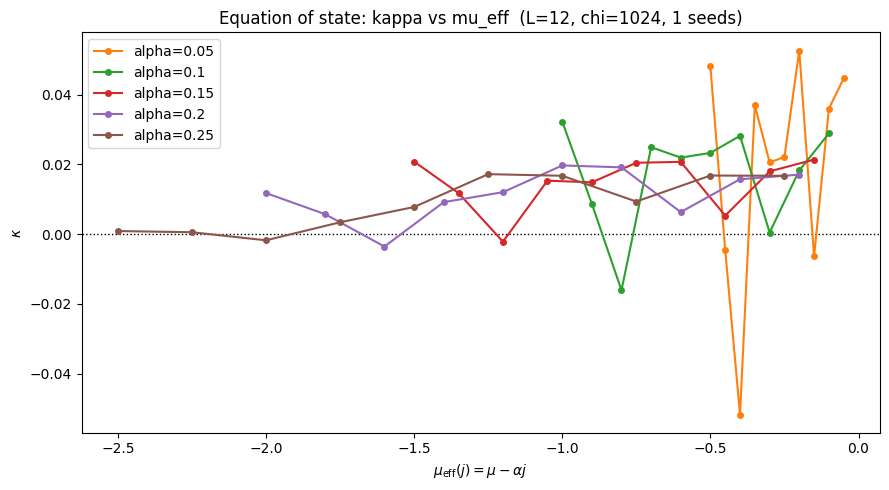

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0.0, color='k', linestyle=':', lw=1.0)

for alpha in alpha_list:
    if alpha == 0.0 or alpha not in kappas_mean:
        continue
    kappa = kappas_mean[alpha]
    err   = kappas_std[alpha]
    mu_eff = - alpha * j_arr
    mask   = ~np.isnan(kappa)
    ax.plot(mu_eff[mask], kappa[mask], '-o', markersize=4,
            color=color_map[alpha], label=f'alpha={alpha}')
    ax.fill_between(mu_eff[mask],
                    (kappa - err)[mask],
                    (kappa + err)[mask],
                    color=color_map[alpha], alpha=0.2)

ax.set_title(
    f'Equation of state: kappa vs mu_eff  '
    f'(L={L}, chi={maxdim}, {len(seed_list)} seeds)'
)
ax.set_xlabel(r'$\mu_{\rm eff}(j) = -\alpha j$')
ax.set_ylabel(r'$\kappa$')
ax.legend()
plt.tight_layout()
plt.show()


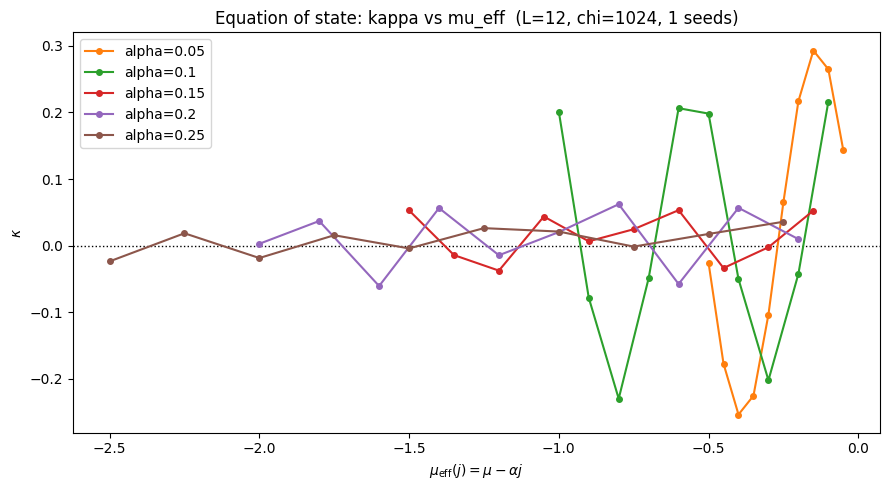

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0.0, color='k', linestyle=':', lw=1.0)

for alpha in alpha_list:
    if alpha == 0.0 or alpha not in kappas_mean:
        continue
    kappa = kappas_mean[alpha]
    err   = kappas_std[alpha]
    mu_eff = - alpha * j_arr
    mask   = ~np.isnan(kappa)
    kappa_hom = wiener_deconvolve(kappa[mask], mu_eff[mask], sigma=0.2, lam=1e-3)
    ax.plot(mu_eff[mask], kappa_hom, '-o', markersize=4,
            color=color_map[alpha], label=f'alpha={alpha}')
    ax.fill_between(mu_eff[mask],
                    (kappa - err)[mask],
                    (kappa + err)[mask],
                    color=color_map[alpha], alpha=0.2)

ax.set_title(
    f'Equation of state: kappa vs mu_eff  '
    f'(L={L}, chi={maxdim}, {len(seed_list)} seeds)'
)
ax.set_xlabel(r'$\mu_{\rm eff}(j) = -\alpha j$')
ax.set_ylabel(r'$\kappa$')
ax.legend()
plt.tight_layout()
plt.show()


# mu_axis and kappa_eff come from your LDA measurement